In [11]:
!pip install -q tensorflow


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [13]:
import tensorflow as tf

print("TensorFlow is ready!")
print("Version:", tf.__version__)

TensorFlow is ready!
Version: 2.20.0


In [14]:
import tensorflow_datasets as tfds

print("Checking PlantVillage dataset...")

builder = tfds.builder("plant_village")
print("Dataset found!")
print("Number of classes:", builder.info.features["label"].num_classes)

Checking PlantVillage dataset...


AttributeError: module 'tensorflow_datasets' has no attribute 'builder'

In [ ]:
!pip install -q --upgrade protobuf tensorflow-datasets

In [1]:
import tensorflow as tf

print("TensorFlow is working!")
print("Version:", tf.__version__)

TensorFlow is working!
Version: 2.20.0


In [5]:
!wget -q --show-progress https://storage.googleapis.com/plantvillage-dataset/plantvillage.zip -O plantvillage.zip

In [6]:
import os

print(os.path.exists("plantvillage.zip"))

True


In [7]:
!unzip -q plantvillage.zip -d plantvillage
print("Dataset extracted successfully!")

[plantvillage.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of plantvillage.zip or
        plantvillage.zip.zip, and cannot find plantvillage.zip.ZIP, period.
Dataset extracted successfully!


In [8]:
import os

dataset_path = "plantvillage"

classes = []

for root, dirs, files in os.walk(dataset_path):
    for folder in dirs:
        classes.append(folder)

classes = sorted(set(classes))

print("Number of categories:", len(classes))
print("First 20 categories:")
print(classes[:20])

Number of categories: 0
First 20 categories:
[]


In [9]:
import os

print(os.listdir("plantvillage"))

FileNotFoundError: [Errno 2] No such file or directory: 'plantvillage'

In [10]:
import os

print(os.listdir())

['.config', 'plantvillage.zip', 'sample_data']


In [11]:
import zipfile
import os

with zipfile.ZipFile("plantvillage.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")

print("Extraction complete!")
print(os.listdir("plantvillage"))

BadZipFile: File is not a zip file

In [12]:
import os

print("File size:", os.path.getsize("plantvillage.zip"), "bytes")

with open("plantvillage.zip", "rb") as f:
    print("First bytes:", f.read(20))

File size: 0 bytes
First bytes: b''


In [13]:
!pip install -q datasets


In [14]:
from datasets import load_dataset

dataset = load_dataset("mohanty/PlantVillage", split="train")

print("Dataset downloaded!")
print("Number of images:", len(dataset))

README.md:   0%|          | 0.00/6.47k [00:00<?, ?B/s]

ValueError: BuilderConfig 'color' not found. Available: ['default']

In [15]:
import os

if os.path.exists("plantvillage.zip"):
    os.remove("plantvillage.zip")

print("Old broken file removed.")

Old broken file removed.


In [16]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0",
    split="train"
)

print("Dataset loaded!")
print("Number of images:", len(dataset))
print("Columns:", dataset.column_names)

README.md:   0%|          | 0.00/549 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  402MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  453MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/54304 [00:00<?, ? examples/s]

Dataset loaded!
Number of images: 54304
Columns: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']


In [17]:
print("Number of categories:", len(set(dataset["class_label"])))

print("\nCategories:")
for category in sorted(set(dataset["class_label"])):
    print(category)

Number of categories: 38

Categories:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_v

In [18]:
import numpy as np

# Get all 38 category names
class_names = sorted(set(dataset["class_label"]))

# Give each category a number: 0, 1, 2, ... 37
class_to_index = {
    name: index for index, name in enumerate(class_names)
}

print("Number of classes:", len(class_names))
print("Example:")
print(class_names[0], "=", class_to_index[class_names[0]])

Number of classes: 38
Example:
Apple___Apple_scab = 0


In [19]:
IMG_SIZE = 224

print("Image size:", IMG_SIZE, "x", IMG_SIZE)
print("Classes ready:", len(class_names))

Image size: 224 x 224
Classes ready: 38


Label: Apple___Apple_scab
Crop: Apple
Disease: Apple scab


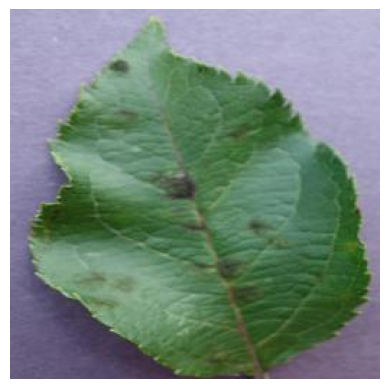

In [20]:
import matplotlib.pyplot as plt

sample = dataset[0]

print("Label:", sample["class_label"])
print("Crop:", sample["host"])
print("Disease:", sample["disease"])

plt.imshow(sample["image"])
plt.axis("off")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=dataset["class_idx"]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))

Training images: 43443
Validation images: 10861


In [22]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully!


In [23]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(38, activation="softmax")
])

print("AgriCare AI model created!")
print("Output classes:", 38)

AgriCare AI model created!
Output classes: 38


In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [25]:
import tensorflow as tf

BATCH_SIZE = 32

def make_dataset(indices):
    images = []
    labels = []

    for i in indices:
        image = dataset[int(i)]["image"]
        image = image.resize((224, 224))
        image = np.array(image).astype("float32") / 255.0

        images.append(image)
        labels.append(class_to_index[dataset[int(i)]["class_label"]])

    return tf.data.Dataset.from_tensor_slices(
        (np.array(images), np.array(labels))
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Batch loader ready!")

Batch loader ready!


In [1]:
train_ds = make_dataset(train_indices)
val_ds = make_dataset(val_indices)

print("Training loader ready!")
print("Validation loader ready!")

NameError: name 'make_dataset' is not defined

In [2]:
import tensorflow as tf
import numpy as np

BATCH_SIZE = 32

def make_dataset(indices):
    images = []
    labels = []

    for i in indices:
        sample = dataset[int(i)]

        image = sample["image"]
        image = image.resize((224, 224))
        image = np.array(image).astype("float32") / 255.0

        images.append(image)
        labels.append(class_to_index[sample["class_label"]])

    return tf.data.Dataset.from_tensor_slices(
        (np.array(images), np.array(labels))
    ).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Batch loader ready!")

Batch loader ready!


In [3]:
train_ds = make_dataset(train_indices)
val_ds = make_dataset(val_indices)

print("Training loader ready!")
print("Validation loader ready!")

NameError: name 'train_indices' is not defined

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

indices = np.arange(len(dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=dataset["class_idx"]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))

NameError: name 'dataset' is not defined

In [5]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0",
    split="train"
)

print("Dataset loaded again!")
print("Images:", len(dataset))

Dataset loaded again!
Images: 54304


In [6]:
import numpy as np

class_names = sorted(set(dataset["class_label"]))

class_to_index = {
    name: index for index, name in enumerate(class_names)
}

print("Number of classes:", len(class_names))
print("First class:", class_names[0])

Number of classes: 38
First class: Apple___Apple_scab


In [7]:
from sklearn.model_selection import train_test_split

indices = np.arange(len(dataset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=dataset["class_idx"]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))

Training images: 43443
Validation images: 10861


In [8]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

def image_generator(indices):
    for i in indices:
        sample = dataset[int(i)]

        image = sample["image"].convert("RGB")
        image = image.resize((IMG_SIZE, IMG_SIZE))
        image = np.array(image).astype("float32")

        # MobileNetV2 preprocessing
        image = preprocess_input(image)

        label = class_to_index[sample["class_label"]]

        yield image, label


def make_dataset(indices):
    ds = tf.data.Dataset.from_generator(
        lambda: image_generator(indices),
        output_signature=(
            tf.TensorSpec(
                shape=(IMG_SIZE, IMG_SIZE, 3),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.int32
            )
        )
    )

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


print("Memory-safe image loader is ready!")

Memory-safe image loader is ready!


In [9]:
train_ds = make_dataset(train_indices)
val_ds = make_dataset(val_indices)

print("Training dataset ready!")
print("Validation dataset ready!")

Training dataset ready!
Validation dataset ready!


In [10]:
images, labels = next(iter(train_ds))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("First label:", labels[0].numpy())

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)
First label: 37


In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

# Build AgriCare AI
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(38, activation="softmax")
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("AgriCare AI model is ready!")
print("Classes:", len(class_names))

AgriCare AI model is ready!
Classes: 38


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
    250/Unknown 354s 1s/step - accuracy: 0.5416 - loss: 1.8427

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0",
    split="train"
)

print("Dataset loaded!")
print("Total images:", len(dataset))

README.md:   0%|          | 0.00/549 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  402MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  453MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/54304 [00:00<?, ? examples/s]

Dataset loaded!
Total images: 54304


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

# Get class labels
class_names = sorted(set(dataset["class_label"]))

class_to_index = {
    name: index for index, name in enumerate(class_names)
}

# Get all indices
indices = np.arange(len(dataset))
labels = np.array(dataset["class_idx"])

# Use 12,000 images for training and 3,000 for validation
train_indices, val_indices = train_test_split(
    indices,
    train_size=12000,
    test_size=3000,
    random_state=42,
    stratify=labels
)

print("Classes:", len(class_names))
print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))


Classes: 38
Training images: 12000
Validation images: 3000


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 16

def image_generator(indices):
    for i in indices:
        sample = dataset[int(i)]

        image = sample["image"].convert("RGB")
        image = image.resize((IMG_SIZE, IMG_SIZE))
        image = np.array(image).astype("float32")
        image = preprocess_input(image)

        label = class_to_index[sample["class_label"]]

        yield image, label


def make_dataset(indices):
    ds = tf.data.Dataset.from_generator(
        lambda: image_generator(indices),
        output_signature=(
            tf.TensorSpec(
                shape=(224, 224, 3),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.int32
            )
        )
    )

    return ds.batch(BATCH_SIZE).prefetch(1)


print("RAM-safe loader created!")

RAM-safe loader created!


In [4]:
train_ds = make_dataset(train_indices)
val_ds = make_dataset(val_indices)

print("Training dataset ready:", len(train_indices), "images")
print("Validation dataset ready:", len(val_indices), "images")

Training dataset ready: 12000 images
Validation dataset ready: 3000 images


In [5]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(38, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("AgriCare AI model ready!")
print("Output classes:", len(class_names))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
AgriCare AI model ready!
Output classes: 38


In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=2,
    verbose=1
)

Epoch 1/2
    605/Unknown 447s 727ms/step - accuracy: 0.6312 - loss: 1.4501

KeyboardInterrupt: 

In [7]:
print("Model is still available:", model is not None)
print("Current model classes:", model.output_shape[-1])

Model is still available: True
Current model classes: 38


In [8]:
history = model.fit(
    train_ds.skip(605),
    validation_data=val_ds.take(50),
    epochs=1,
    verbose=1
)

    145/Unknown 138s 690ms/step - accuracy: 0.9086 - loss: 0.3505

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


145/145 ━━━━━━━━━━━━━━━━━━━━ 182s 994ms/step - accuracy: 0.9095 - loss: 0.3462 - val_accuracy: 0.9150 - val_loss: 0.3147


In [9]:
model.save("agricare_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [10]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved!")
print("Total classes:", len(class_names))



Class names saved!
Total classes: 38


In [11]:
from tensorflow.keras.models import load_model

test_model = load_model("agricare_model.keras")

print("Saved model loaded successfully!")
print("Model output classes:", test_model.output_shape[-1])

Saved model loaded successfully!
Model output classes: 38


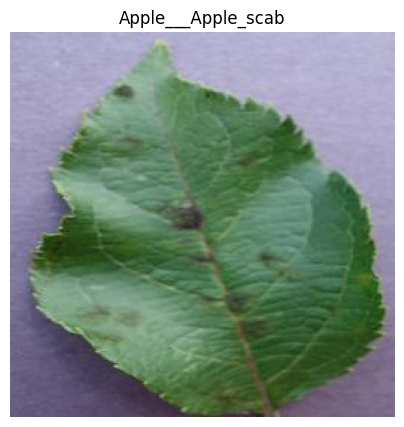

In [12]:
import matplotlib.pyplot as plt

# Take one real image from the dataset
sample = dataset[0]

plt.figure(figsize=(5, 5))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(sample["class_label"])
plt.show()


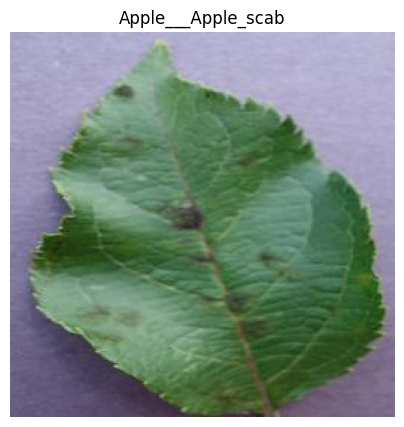

In [13]:
import matplotlib.pyplot as plt

sample = dataset[0]

plt.figure(figsize=(5, 5))
plt.imshow(sample["image"])
plt.axis("off")
plt.title(sample["class_label"])
plt.show()

In [14]:
from PIL import Image
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

sample = dataset[0]

# Prepare image
image = sample["image"].convert("RGB").resize((224, 224))
image_array = np.array(image).astype("float32")
image_array = preprocess_input(image_array)
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = test_model.predict(image_array, verbose=0)[0]

predicted_index = int(np.argmax(prediction))
predicted_class = class_names[predicted_index]
confidence = prediction[predicted_index] * 100

print("Actual:", sample["class_label"])
print("Predicted:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

Actual: Apple___Apple_scab
Predicted: Apple___Apple_scab
Confidence: 90.73%


In [15]:
%%writefile app.py

import streamlit as st

st.set_page_config(
    page_title="AgriCare AI",
    page_icon="🌱",
    layout="centered"
)

st.title("🌱 AgriCare AI")
st.subheader("Smart Crop Leaf Disease Detection")

st.write(
    "Upload a crop leaf image and our AI will identify "
    "the crop and possible disease."
)

uploaded_file = st.file_uploader(
    "📷 Upload a leaf image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:
    st.image(uploaded_file, caption="Uploaded Leaf", use_container_width=True)
    st.success("Image uploaded successfully! 🌿")

Writing app.py


In [16]:
%%writefile app.py

import streamlit as st

st.set_page_config(
    page_title="AgriCare AI",
    page_icon="🌱",
    layout="centered"
)

st.title("🌱 AgriCare AI")
st.subheader("Smart Crop Leaf Disease Detection")

st.write(
    "Upload a crop leaf image and our AI will identify "
    "the crop and possible disease."
)

uploaded_file = st.file_uploader(
    "📷 Upload a leaf image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file:
    st.image(uploaded_file, caption="Uploaded Leaf", use_container_width=True)
    st.success("Image uploaded successfully! 🌿")



Overwriting app.py


In [17]:
import os

print("Model exists:", os.path.exists("agricare_model.keras"))
print("Class names exist:", os.path.exists("class_names.json"))
print("App exists:", os.path.exists("app.py"))


Model exists: True
Class names exist: True
App exists: True


In [18]:
%%writefile app.py

import streamlit as st
import numpy as np
import json
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

st.set_page_config(
    page_title="AgriCare AI",
    page_icon="🌱",
    layout="centered"
)

# Load AI model
@st.cache_resource
def load_ai_model():
    return load_model("agricare_model.keras")

model = load_ai_model()

# Load class names
with open("class_names.json", "r") as f:
    class_names = json.load(f)

st.title("🌱 AgriCare AI")
st.subheader("Smart Crop Leaf Disease Detection")

st.write(
    "Upload a crop leaf image and AgriCare AI will "
    "identify the crop and possible disease."
)

uploaded_file = st.file_uploader(
    "📷 Upload a leaf image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded Leaf",
        use_container_width=True
    )

    if st.button("🔍 Detect Disease"):

        # Prepare image
        processed_image = image.resize((224, 224))
        image_array = np.array(processed_image).astype("float32")

        image_array = preprocess_input(image_array)
        image_array = np.expand_dims(image_array, axis=0)

        # AI prediction
        prediction = model.predict(image_array, verbose=0)[0]

        predicted_index = int(np.argmax(prediction))
        predicted_class = class_names[predicted_index]
        confidence = float(prediction[predicted_index] * 100)

        # Separate crop and disease
        crop, disease = predicted_class.split("___", 1)

        st.success("✅ Detection Complete!")

        st.write("### 🌾 Crop")
        st.write(crop.replace("_", " "))

        st.write("### 🦠 Disease")
        st.write(disease.replace("_", " "))

        st.write("### 🎯 Confidence")
        st.write(f"{confidence:.2f}%")

Overwriting app.py


In [19]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.0 MB/s eta 0:00:00


In [20]:
!streamlit run app.py &>/content/streamlit.log &

In [21]:
!wget -qO- ipv4.icanhazip.com

34.182.120.11


In [22]:
!pip install -q pyngrok

In [23]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("🌱 AgriCare AI Website:")
print(public_url)

ERROR:pyngrok.process.ngrok:t=2026-09-19T18:51:21+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-09-19T18:51:21+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
CRITICAL:pyngrok.process.ngrok:t=2026-09-19T18:51:21+0000 lvl=crit msg="command failed" err="authentication failed: This ngrok session is not authenticated. ngrok requi

PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [24]:
!pkill -f streamlit

In [25]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [26]:
from google.colab.output import eval_js

print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-usw1c2-yxdlf1fs31bz-c.us-west1-2.prod.colab.dev


In [27]:
from PIL import Image

sample = dataset[0]["image"]
sample.save("apple_scab_test.jpg")

print("Saved as apple_scab_test.jpg")

Saved as apple_scab_test.jpg


In [28]:
!cat /content/streamlit.log



2026-09-19 18:52:10.870 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.120.11:8501

2026-09-19 18:53:01.669 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-yxdlf1fs31bz-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-yxdlf1fs31bz.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-09-19 18:53:03.007 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-yxdlf1fs31bz-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-yxdlf1fs31bz.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-09-19 18:53:05.790 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-yxdlf1fs31bz-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-yxdlf1fs31bz.us-west1-c.c.codatalab-user-runtimes.internal:8

In [29]:
!pkill -f streamlit

In [30]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [31]:
!tail -n 15 /content/streamlit.log



2026-09-19 18:56:23.368 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.120.11:8501



In [32]:
from google.colab import files

sample = dataset[0]["image"]
sample.save("apple_scab_test.jpg")

files.download("apple_scab_test.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
%%writefile app.py

import streamlit as st
import numpy as np
import json
from PIL import Image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# =========================================================
# PAGE SETTINGS
# =========================================================

st.set_page_config(
    page_title="AgriCare AI",
    page_icon="🌱",
    layout="wide",
    initial_sidebar_state="collapsed"
)

# =========================================================
# CUSTOM DESIGN
# =========================================================

st.markdown("""
<style>

@import url('https://fonts.googleapis.com/css2?family=DM+Sans:wght@400;500;600;700&display=swap');

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
}

.stApp {
    background:
        radial-gradient(circle at 10% 10%, #e8f7df 0%, transparent 25%),
        radial-gradient(circle at 90% 20%, #dff5e5 0%, transparent 25%),
        linear-gradient(135deg, #f8fff5 0%, #eef9f0 100%);
}

/* Main container */
.block-container {
    padding-top: 2rem;
    padding-bottom: 3rem;
    max-width: 1150px;
}

/* Hero */
.hero {
    background: linear-gradient(135deg, #14532d, #228b45);
    padding: 45px 40px;
    border-radius: 28px;
    color: white;
    margin-bottom: 30px;
    box-shadow: 0 15px 40px rgba(20,83,45,0.18);
}

.hero h1 {
    font-size: 48px;
    margin-bottom: 10px;
    font-weight: 700;
}

.hero p {
    font-size: 19px;
    opacity: 0.92;
    line-height: 1.6;
}

/* Cards */
.card {
    background: rgba(255,255,255,0.88);
    border-radius: 22px;
    padding: 25px;
    border: 1px solid #dceedd;
    box-shadow: 0 8px 25px rgba(31,75,45,0.08);
    margin-bottom: 20px;
}

.result-card {
    background: linear-gradient(135deg, #ffffff, #f1faef);
    border: 2px solid #bde2bd;
    border-radius: 25px;
    padding: 30px;
    box-shadow: 0 12px 35px rgba(31,75,45,0.10);
}

.info-card {
    background: white;
    border-radius: 20px;
    padding: 22px;
    border-left: 6px solid #39a852;
    box-shadow: 0 6px 20px rgba(31,75,45,0.07);
    height: 100%;
}

.info-card h3 {
    color: #176b35;
}

.metric-card {
    background: white;
    padding: 22px;
    border-radius: 20px;
    text-align: center;
    border: 1px solid #dceedd;
    box-shadow: 0 5px 18px rgba(31,75,45,0.06);
}

.metric-number {
    font-size: 30px;
    font-weight: 700;
    color: #176b35;
}

.metric-label {
    color: #64748b;
}

/* Upload box */
[data-testid="stFileUploader"] {
    background: white;
    border-radius: 20px;
    padding: 10px;
    border: 2px dashed #8dcc8d;
}

/* Button */
.stButton > button {
    width: 100%;
    border-radius: 14px;
    background: linear-gradient(135deg, #1b7a3c, #32a852);
    color: white;
    font-size: 17px;
    font-weight: 600;
    padding: 13px;
    border: none;
    box-shadow: 0 6px 15px rgba(27,122,60,0.20);
}

.stButton > button:hover {
    background: linear-gradient(135deg, #145c2d, #238c43);
    transform: translateY(-1px);
}

.footer {
    text-align: center;
    padding: 25px;
    color: #64748b;
    font-size: 14px;
}

</style>
""", unsafe_allow_html=True)

# =========================================================
# LOAD MODEL
# =========================================================

@st.cache_resource
def load_ai_model():
    return load_model("agricare_model.keras")

model = load_ai_model()

with open("class_names.json", "r") as f:
    class_names = json.load(f)

# =========================================================
# DISEASE INFORMATION
# =========================================================

disease_info = {

    "Apple scab": {
        "symptoms": "Dark olive or brown spots may appear on leaves. Infected areas can become darker and may affect leaf growth.",
        "prevention": "Remove fallen infected leaves, maintain good airflow around trees, and avoid prolonged leaf wetness.",
        "management": "Monitor the crop regularly and follow locally recommended fungicide or cultural-control practices when necessary."
    },

    "Black rot": {
        "symptoms": "Dark circular lesions can develop on leaves and infected plant tissue may gradually become brown or black.",
        "prevention": "Remove infected plant material and maintain good orchard or field sanitation.",
        "management": "Prune affected material where appropriate and follow locally recommended disease-management practices."
    },

    "Cedar apple rust": {
        "symptoms": "Yellow-orange spots can appear on apple leaves and may become more noticeable as the disease develops.",
        "prevention": "Remove infected plant debris and manage nearby alternate hosts where appropriate.",
        "management": "Monitor new leaf growth and follow locally recommended disease-control practices."
    },

    "Powdery mildew": {
        "symptoms": "White, powdery fungal growth may appear on leaf surfaces and young plant parts.",
        "prevention": "Improve airflow, avoid excessive humidity around foliage, and maintain appropriate plant spacing.",
        "management": "Remove heavily affected material where practical and use locally recommended controls."
    },

    "Bacterial spot": {
        "symptoms": "Small dark or water-soaked spots can appear on leaves and may enlarge under favorable conditions.",
        "prevention": "Use healthy planting material, reduce unnecessary leaf wetness, and maintain field sanitation.",
        "management": "Remove severely affected material where practical and follow local agricultural recommendations."
    },

    "Early blight": {
        "symptoms": "Brown or dark leaf spots may develop, sometimes forming concentric ring patterns.",
        "prevention": "Maintain field sanitation, avoid prolonged leaf wetness, and provide adequate spacing.",
        "management": "Remove severely affected leaves and follow locally recommended disease-management practices."
    },

    "Late blight": {
        "symptoms": "Dark irregular lesions can develop rapidly on leaves, especially under cool and wet conditions.",
        "prevention": "Avoid prolonged leaf wetness, maintain good airflow, and monitor plants frequently during favorable weather.",
        "management": "Remove severely infected plant material and follow locally recommended disease-control practices."
    },

    "Leaf Mold": {
        "symptoms": "Yellowish areas may appear on the upper leaf surface with fungal growth developing on the underside.",
        "prevention": "Improve ventilation and avoid excessive humidity around foliage.",
        "management": "Remove affected leaves where practical and follow locally recommended controls."
    },

    "Septoria leaf spot": {
        "symptoms": "Small circular leaf spots may develop with darker margins and lighter centers.",
        "prevention": "Remove infected plant debris and avoid splashing water onto foliage.",
        "management": "Monitor lower leaves and follow locally recommended disease-management practices."
    },

    "Spider mites Two-spotted spider mite": {
        "symptoms": "Leaves may develop pale speckling, yellowing, or a dusty appearance. Fine webbing may occur in severe cases.",
        "prevention": "Monitor plants regularly and reduce conditions that encourage mite outbreaks.",
        "management": "Use appropriate integrated pest-management practices and locally recommended controls."
    },

    "Target Spot": {
        "symptoms": "Dark circular lesions may appear on leaves and can enlarge as infection progresses.",
        "prevention": "Improve airflow, maintain sanitation, and avoid prolonged moisture on foliage.",
        "management": "Remove heavily affected leaves where practical and follow local recommendations."
    },

    "Tomato Yellow Leaf Curl Virus": {
        "symptoms": "Leaves may curl upward, become smaller, and show yellowing or stunted growth.",
        "prevention": "Monitor and manage insect vectors such as whiteflies and use healthy planting material.",
        "management": "Remove severely affected plants where appropriate and follow local integrated pest-management guidance."
    },

    "Tomato mosaic virus": {
        "symptoms": "Leaves may show mottled light and dark green patterns, distortion, and reduced plant growth.",
        "prevention": "Use clean tools and healthy planting material and avoid spreading plant sap between plants.",
        "management": "Remove infected plants where appropriate and maintain strict field hygiene."
    }
}

# =========================================================
# HEADER
# =========================================================

st.markdown("""
<div class="hero">

<h1>🌱 AgriCare AI</h1>

<p>
<b>Smart Crop Leaf Disease Detection</b><br>
Snap a photo. Upload it. Let AI help you understand your crop.
</p>

<p>
🚜 Built for farmers &nbsp; • &nbsp;
🤖 AI-powered &nbsp; • &nbsp;
⚡ Fast detection
</p>

</div>
""", unsafe_allow_html=True)

# =========================================================
# QUICK STATS
# =========================================================

c1, c2, c3 = st.columns(3)

with c1:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-number">38</div>
        <div class="metric-label">Crop & Disease Classes</div>
    </div>
    """, unsafe_allow_html=True)

with c2:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-number">224×224</div>
        <div class="metric-label">AI Image Processing</div>
    </div>
    """, unsafe_allow_html=True)

with c3:
    st.markdown("""
    <div class="metric-card">
        <div class="metric-number">⚡ Fast</div>
        <div class="metric-label">MobileNetV2 Model</div>
    </div>
    """, unsafe_allow_html=True)

st.write("")

# =========================================================
# DETECTION AREA
# =========================================================

st.markdown("""
<div class="card">

<h2>📸 Check Your Plant</h2>

<p>
Upload a clear photo of the affected leaf.
For better results, keep the leaf visible and well lit.
</p>

</div>
""", unsafe_allow_html=True)

uploaded_file = st.file_uploader(
    "🌿 Choose a leaf photo",
    type=["jpg", "jpeg", "png"],
    label_visibility="collapsed"
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns([1.1, 1])

    with col1:
        st.image(
            image,
            caption="🌿 Your Leaf",
            use_container_width=True
        )

    with col2:

        st.markdown("""
        <div class="card">

        <h3>🔍 Ready to inspect?</h3>

        <p>
        Our AI will analyze the visual patterns in the leaf
        and compare them with its trained crop-disease classes.
        </p>

        </div>
        """, unsafe_allow_html=True)

        detect = st.button("🔍 Detect Disease")

    if detect:

        with st.spinner("🤖 AgriCare AI is examining your leaf..."):

            processed_image = image.resize((224, 224))

            image_array = np.array(
                processed_image
            ).astype("float32")

            image_array = preprocess_input(image_array)

            image_array = np.expand_dims(
                image_array,
                axis=0
            )

            prediction = model.predict(
                image_array,
                verbose=0
            )[0]

            predicted_index = int(
                np.argmax(prediction)
            )

            predicted_class = class_names[
                predicted_index
            ]

            confidence = float(
                prediction[predicted_index] * 100
            )

            crop, disease = predicted_class.split(
                "___",
                1
            )

            crop = crop.replace("_", " ")
            disease = disease.replace("_", " ")

        # =================================================
        # RESULT
        # =================================================

        st.write("")

        st.markdown("""
        <div class="result-card">

        <h2>🎉 Detection Complete!</h2>

        </div>
        """, unsafe_allow_html=True)

        r1, r2, r3 = st.columns(3)

        with r1:
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size:38px;">🌾</div>
                <div class="metric-label">Crop</div>
                <div class="metric-number">{crop}</div>
            </div>
            """, unsafe_allow_html=True)

        with r2:
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size:38px;">🦠</div>
                <div class="metric-label">Condition</div>
                <div class="metric-number" style="font-size:23px;">
                    {disease}
                </div>
            </div>
            """, unsafe_allow_html=True)

        with r3:
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size:38px;">🎯</div>
                <div class="metric-label">AI Confidence</div>
                <div class="metric-number">
                    {confidence:.1f}%
                </div>
            </div>
            """, unsafe_allow_html=True)

        st.write("")

        st.progress(
            min(int(confidence), 100),
            text=f"AI confidence: {confidence:.2f}%"
        )

        # =================================================
        # HEALTHY PLANT
        # =================================================

        if "healthy" in disease.lower():

            st.success(
                "🌿 Good news! The model classified this "
                "leaf as healthy."
            )

            st.info(
                "Continue regular monitoring, proper watering, "
                "good nutrition, and healthy field practices."
            )

        # =================================================
        # DISEASE INFORMATION
        # =================================================

        else:

            info = disease_info.get(
                disease,
                {
                    "symptoms":
                        "Visible symptoms can vary depending on crop stage and growing conditions.",

                    "prevention":
                        "Maintain field sanitation, good airflow, and regular crop monitoring.",

                    "management":
                        "Follow locally recommended agricultural disease-management practices."
                }
            )

            st.write("")

            st.markdown(
                "<h2>🌿 What should you know?</h2>",
                unsafe_allow_html=True
            )

            a, b, c = st.columns(3)

            with a:
                st.markdown(f"""
                <div class="info-card">
                    <h3>🔎 Symptoms</h3>
                    <p>{info["symptoms"]}</p>
                </div>
                """, unsafe_allow_html=True)

            with b:
                st.markdown(f"""
                <div class="info-card">
                    <h3>🛡️ Prevention</h3>
                    <p>{info["prevention"]}</p>
                </div>
                """, unsafe_allow_html=True)

            with c:
                st.markdown(f"""
                <div class="info-card">
                    <h3>🌱 Management</h3>
                    <p>{info["management"]}</p>
                </div>
                """, unsafe_allow_html=True)

            st.warning(
                "⚠️ AI predictions are for preliminary guidance. "
                "For serious crop damage, confirm the diagnosis "
                "with a qualified agricultural expert before "
                "taking treatment decisions."
            )

# =========================================================
# HOW IT WORKS
# =========================================================

st.write("")
st.write("")

st.markdown(
    "<h2>🤖 How AgriCare AI Works</h2>",
    unsafe_allow_html=True
)

h1, h2, h3, h4 = st.columns(4)

with h1:
    st.markdown("""
    <div class="info-card">
        <h3>1️⃣ Upload</h3>
        <p>Take or upload a clear photo of your crop leaf.</p>
    </div>
    """, unsafe_allow_html=True)

with h2:
    st.markdown("""
    <div class="info-card">
        <h3>2️⃣ Process</h3>
        <p>The image is resized and prepared for the AI model.</p>
    </div>
    """, unsafe_allow_html=True)

with h3:
    st.markdown("""
    <div class="info-card">
        <h3>3️⃣ Analyze</h3>
        <p>MobileNetV2 analyzes visual patterns in the leaf.</p>
    </div>
    """, unsafe_allow_html=True)

with h4:
    st.markdown("""
    <div class="info-card">
        <h3>4️⃣ Discover</h3>
        <p>See the predicted crop, condition and confidence.</p>
    </div>
    """, unsafe_allow_html=True)

# =========================================================
# FARMER TIPS
# =========================================================

st.write("")
st.write("")

with st.expander("🌾 Everyday Crop Care Tips"):

    st.markdown("""
    ### 🌱 Keep checking your plants
    Early observation can help identify unusual leaf changes.

    ### 💧 Water wisely
    Avoid unnecessary prolonged moisture on leaves.

    ### ☀️ Give plants enough space
    Good airflow can help reduce favorable conditions for some diseases.

    ### 🧹 Keep the field clean
    Remove appropriate infected plant material and maintain sanitation.

    ### 🔍 Check regularly
    Look at both new and older leaves for unusual spots, discoloration,
    curling, or fungal growth.
    """)

# =========================================================
# FOOTER
# =========================================================

st.markdown("""
<div class="footer">

🌱 <b>AgriCare AI</b> — Smart technology for smarter farming.

<br><br>

Built with ❤️ using Python, TensorFlow, MobileNetV2 & Streamlit.

<br><br>

<small>
AI results are intended for preliminary crop-health guidance
and should not replace professional agricultural diagnosis.
</small>

</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [39]:
!pkill -f streamlit

In [40]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [42]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [43]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [44]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [45]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [46]:
import os
import zipfile
from google.colab import files

# Folder where our test images will be saved
test_folder = "AgriCare_Test_Images"
os.makedirs(test_folder, exist_ok=True)

# Get one image from each of the 38 classes
selected = {}

for i in range(len(dataset)):
    label = dataset[i]["class_label"]

    # Keep only the first image from each class
    if label not in selected:
        selected[label] = i

    # Stop once we have all 38 classes
    if len(selected) == 38:
        break

# Save the images
for label, index in selected.items():
    image = dataset[index]["image"].convert("RGB")

    # Make a simple filename
    filename = label.replace("/", "_").replace(" ", "_") + ".jpg"

    image.save(
        os.path.join(test_folder, filename),
        "JPEG"
    )

print("✅ Test images created!")
print("Number of categories:", len(selected))

# Create ZIP file
zip_name = "AgriCare_38_Test_Images.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    for filename in os.listdir(test_folder):
        filepath = os.path.join(test_folder, filename)
        zipf.write(filepath, arcname=filename)

print("✅ ZIP file created:", zip_name)

# Download the ZIP
files.download(zip_name)

✅ Test images created!
Number of categories: 38
✅ ZIP file created: AgriCare_38_Test_Images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [48]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [49]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [50]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [51]:
!streamlit run app.py \
  --server.port 8501 \
  --server.address 0.0.0.0 \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > /content/streamlit.log 2>&1 &

In [52]:
from google.colab import files

files.download("app.py")
files.download("agricare_model.keras")
files.download("class_names.json")

with open("requirements.txt", "w") as f:
    f.write("""streamlit
tensorflow
pillow
numpy
""")

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [53]:
import sys
print(sys.version)

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [1]:
from sklearn.model_selection import train_test_split
import numpy as np

# All dataset indices
all_indices = np.arange(len(dataset))

# Images not used for training or validation
used_indices = np.concatenate([train_indices, val_indices])
remaining_indices = np.setdiff1d(all_indices, used_indices)

# Select 3,000 unseen test images, stratified across the 38 classes
test_indices, _ = train_test_split(
    remaining_indices,
    train_size=3000,
    random_state=42,
    stratify=np.array(dataset["class_idx"])[remaining_indices]
)

# Create test dataset
test_ds = make_dataset(test_indices)

# Evaluate the trained model
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

NameError: name 'dataset' is not defined

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "geraldmc/plantvillage-full",
    revision="v0.1.0",
    split="train"
)

print("Dataset loaded:", len(dataset))

README.md:   0%|          | 0.00/549 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  402MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  453MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/54304 [00:00<?, ? examples/s]

Dataset loaded: 54304


In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf

# Load your saved model
model = load_model("agricare_model.keras")

# Recreate the same class mapping
class_names = sorted(list(set(dataset["class_label"])))
class_to_index = {name: i for i, name in enumerate(class_names)}

# Recreate the same training and validation split
all_indices = np.arange(len(dataset))
labels = np.array(dataset["class_idx"])

train_indices, val_indices = train_test_split(
    all_indices,
    train_size=12000,
    test_size=3000,
    random_state=42,
    stratify=labels
)

# Everything outside train + validation is unseen
used_indices = np.concatenate([train_indices, val_indices])
remaining_indices = np.setdiff1d(all_indices, used_indices)

# Select 3,000 unseen test images
test_indices, _ = train_test_split(
    remaining_indices,
    train_size=3000,
    random_state=42,
    stratify=labels[remaining_indices]
)

print("Model loaded successfully!")
print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Unseen test images:", len(test_indices))

ValueError: File not found: filepath=agricare_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [4]:
https://github.com/YOUR-USERNAME/flora-recognition

SyntaxError: invalid syntax (1774945944.py, line 1)

In [5]:
!git clone https://github.com/nidhahaha24-debug/flora-recognition.git

Cloning into 'flora-recognition'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 8.58 MiB | 10.81 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [6]:
from tensorflow.keras.models import load_model

model = load_model("/content/flora-recognition/agricare_model.keras")

print("Model loaded successfully!")
print("Output classes:", model.output_shape[-1])

Model loaded successfully!
Output classes: 38


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

# Get all dataset indices and labels
all_indices = np.arange(len(dataset))
labels = np.array(dataset["class_idx"])

# Recreate the original training + validation split
train_indices, val_indices = train_test_split(
    all_indices,
    train_size=12000,
    test_size=3000,
    random_state=42,
    stratify=labels
)

# Everything else was NOT used in training/validation
used_indices = np.concatenate([train_indices, val_indices])
remaining_indices = np.setdiff1d(all_indices, used_indices)

# Select 3,000 completely unseen test images
test_indices, _ = train_test_split(
    remaining_indices,
    train_size=3000,
    random_state=42,
    stratify=labels[remaining_indices]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Unseen test images:", len(test_indices))

Training images: 12000
Validation images: 3000
Unseen test images: 3000


In [8]:
# Create the unseen test dataset
test_ds = make_dataset(test_indices)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\n==============================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("==============================")

NameError: name 'make_dataset' is not defined

In [9]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 16

# Recreate class mapping
class_names = sorted(list(set(dataset["class_label"])))
class_to_index = {name: i for i, name in enumerate(class_names)}

def image_generator(indices):
    for i in indices:
        sample = dataset[int(i)]

        image = sample["image"].convert("RGB")
        image = image.resize((IMG_SIZE, IMG_SIZE))
        image = np.array(image).astype("float32")
        image = preprocess_input(image)

        label = class_to_index[sample["class_label"]]

        yield image, label

def make_dataset(indices):
    ds = tf.data.Dataset.from_generator(
        lambda: image_generator(indices),
        output_signature=(
            tf.TensorSpec(
                shape=(224, 224, 3),
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=(),
                dtype=tf.int32
            )
        )
    )

    return ds.batch(BATCH_SIZE).prefetch(1)

print("Test dataset function ready!")

Test dataset function ready!


In [10]:
test_ds = make_dataset(test_indices)

test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("\n==============================")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print("==============================")

188/188 ━━━━━━━━━━━━━━━━━━━━ 126s 642ms/step - accuracy: 0.9153 - loss: 0.3171

Test Loss: 0.3171
Test Accuracy: 91.53%


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [12]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Get predictions for the same 3,000 test images
y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Images evaluated:", len(y_true))
print("Predictions generated successfully!")

Images evaluated: 3000
Predictions generated successfully!


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true, y_pred,
    average="weighted",
    zero_division=0
)

print("================================")
print(f"Weighted Precision: {precision * 100:.2f}%")
print(f"Weighted Recall:    {recall * 100:.2f}%")
print(f"Weighted F1-score:  {f1 * 100:.2f}%")
print("================================")

Weighted Precision: 91.88%
Weighted Recall:    91.53%
Weighted F1-score:  91.41%


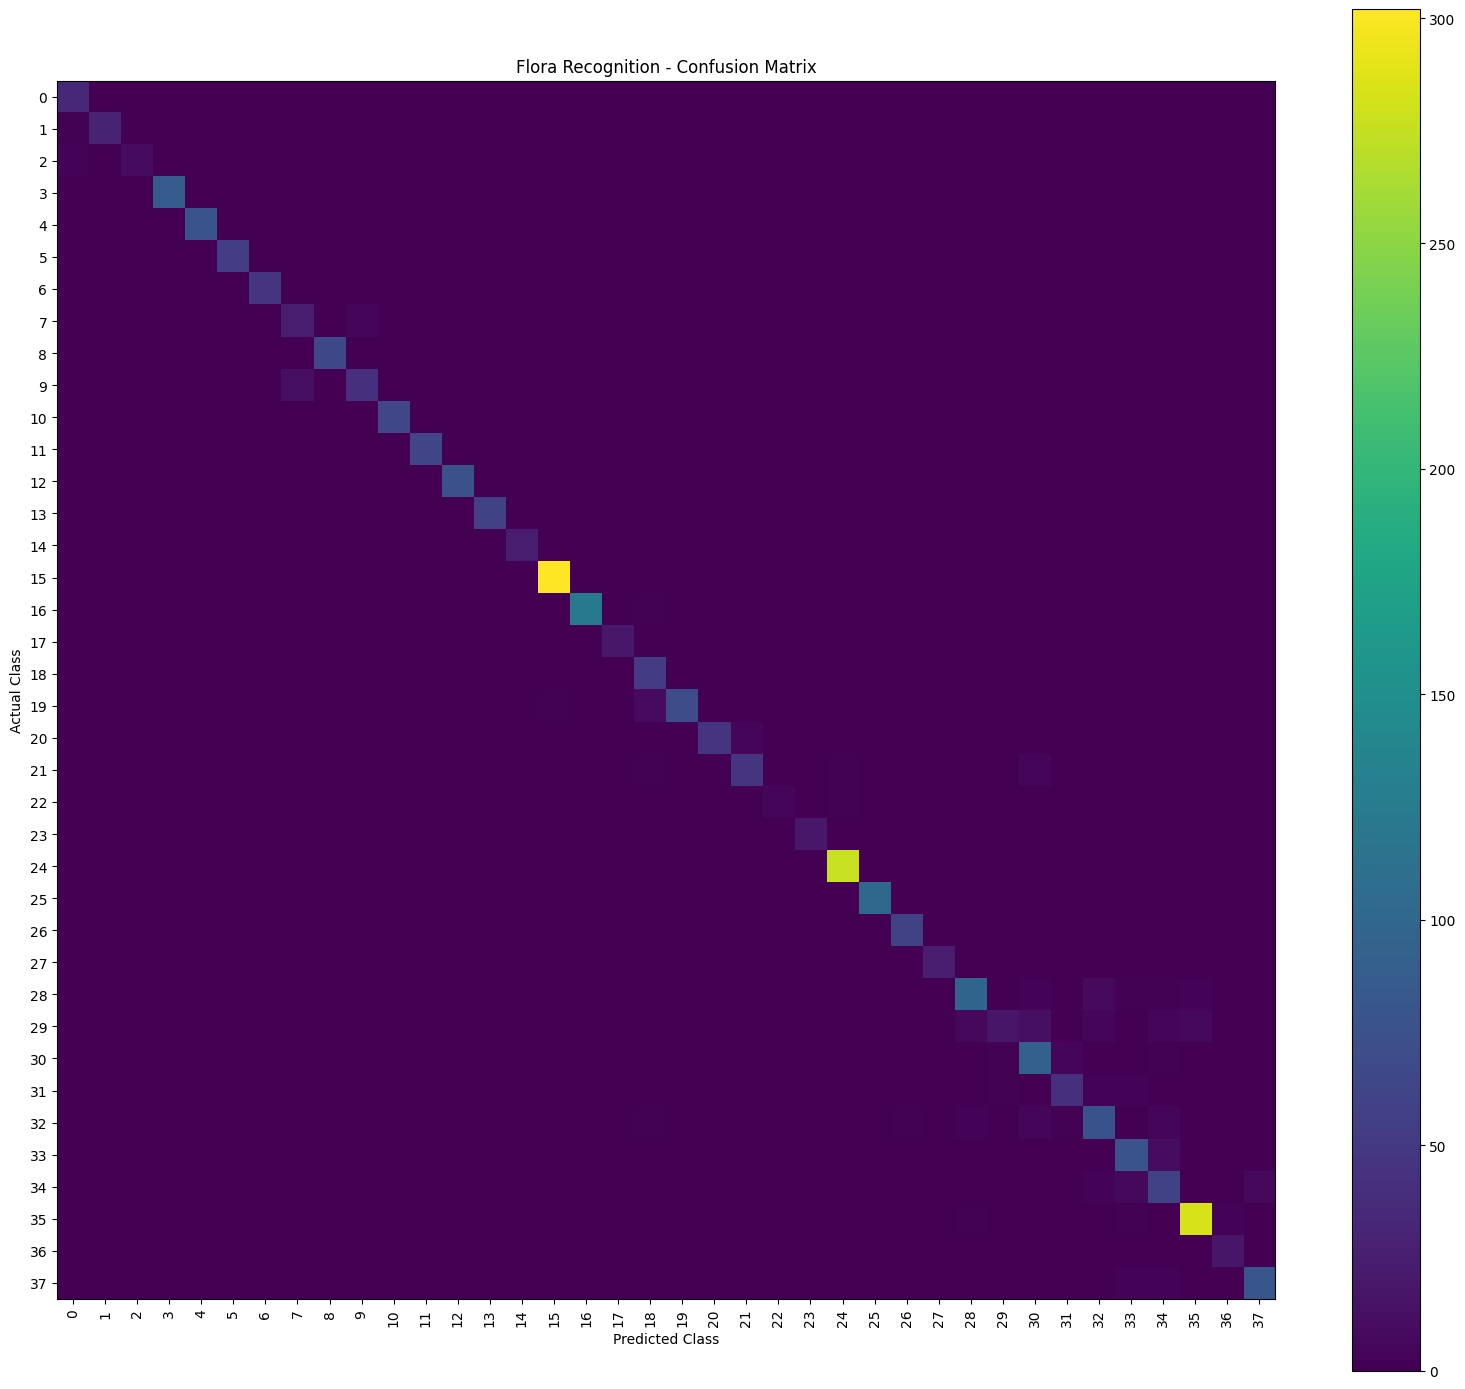

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 14))
plt.imshow(cm, interpolation="nearest")
plt.title("Flora Recognition - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.colorbar()

plt.xticks(
    range(len(class_names)),
    range(len(class_names)),
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    range(len(class_names))
)

plt.tight_layout()
plt.show()

In [15]:
import time
import numpy as np

# Take one batch from the test dataset
test_batch_images, _ = next(iter(test_ds))

# Warm-up run (not included in timing)
_ = model.predict(test_batch_images, verbose=0)

# Measure prediction time
start_time = time.perf_counter()

_ = model.predict(test_batch_images, verbose=0)

end_time = time.perf_counter()

batch_time = end_time - start_time
batch_size = test_batch_images.shape[0]

time_per_image_ms = (batch_time / batch_size) * 1000

print("====================================")
print(f"Batch size: {batch_size}")
print(f"Batch inference time: {batch_time:.4f} seconds")
print(f"Average inference time per image: {time_per_image_ms:.2f} ms")
print("====================================")

Batch size: 16
Batch inference time: 1.4388 seconds
Average inference time per image: 89.93 ms
